# Flipkart Gridlock Hackathon: Event-Driven Congestion Prediction
## XGBoost Classification Model & Pipeline

### Project Goal
This notebook implements a complete Machine Learning pipeline to predict traffic **congestion levels** (`Low`, `Medium`, `High`) based on event characteristics.

### Pipeline Outline
1. **Load Processed Data**: Load `processed_congestion_data.csv`.
2. **Feature Preparation**:
   - Compute `duration_hours` from `duration_minutes`.
   - Create `day_of_week` from `weekday`.
   - Map `congestion_proxy_label` to target `congestion_level` (0, 1, 2).
3. **Preprocessing Pipeline**: Build a scikit-learn `ColumnTransformer` to handle:
   - Categorical features (One-Hot Encoding).
   - Numerical features (Scaling).
4. **Train/Test Split**: 80/20 train-test split, stratified to preserve class distributions.
5. **Model Training**: Train an `XGBClassifier` optimized for multi-class classification.
6. **Model Evaluation**: Print a classification report and plot a confusion matrix.
7. **Model Serialization**: Save the entire pipeline (preprocessor + model) using `joblib`.


In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')

# Style configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [8, 6]
plt.rcParams['font.size'] = 11

print("Imported required libraries and set visualization styles.")

Imported required libraries and set visualization styles.


In [2]:
# Load dataset
file_path = "processed_congestion_data.csv"
if not os.path.exists(file_path):
    raise FileNotFoundError(f"File '{file_path}' not found. Please run the EDA notebook first.")

df = pd.read_csv(file_path)
print(f"Loaded processed data with shape: {df.shape}")

# Prepare features
df['duration_hours'] = df['duration_minutes'] / 60.0
df['day_of_week'] = df['weekday']

# Map target label to integer categories: Low=0, Medium=1, High=2
target_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['congestion_level'] = df['congestion_proxy_label'].map(target_map)

print("\nValue distribution of target congestion_level:")
print(df['congestion_proxy_label'].value_counts())
print(df['congestion_level'].value_counts())

# Select input features and target
features = [
    'event_type', 'event_cause', 'priority', 'requires_road_closure',
    'hour', 'day_of_week', 'duration_hours', 'zone', 'junction'
]
target = 'congestion_level'

X = df[features]
y = df[target]

print(f"\nFeature dimensions: {X.shape}")
print(f"Target dimensions: {y.shape}")
X.head()

Loaded processed data with shape: (8173, 17)

Value distribution of target congestion_level:
congestion_proxy_label
Medium    4362
Low       2631
High      1180
Name: count, dtype: int64
congestion_level
1    4362
0    2631
2    1180
Name: count, dtype: int64

Feature dimensions: (8173, 9)
Target dimensions: (8173,)


,event_type,event_cause,priority,requires_road_closure,hour,day_of_week,duration_hours,zone,junction
0,unplanned,vehicle_breakdown,High,False,17.0,3.0,0.685046,Unknown,Unknown
1,unplanned,vehicle_breakdown,High,False,4.0,1.0,0.172960,Unknown,Unknown
2,unplanned,others,Low,False,6.0,5.0,1918.633316,Central Zone 2,UrvashiJunction
3,unplanned,tree_fall,Low,True,17.0,3.0,157.752913,Unknown,Unknown
4,unplanned,vehicle_breakdown,Low,False,4.0,1.0,0.645831,Unknown,LalbaghMainGateJunc


## 1. Preprocessing Pipeline
To handle a mix of numerical, categorical, and boolean features, we define a standard scikit-learn preprocessing pipeline:
- **Numerical Features** (`hour`, `day_of_week`, `duration_hours`): Normalized using `StandardScaler`.
- **Categorical Features** (`event_type`, `event_cause`, `priority`, `zone`, `junction`): Encoded using `OneHotEncoder` with `handle_unknown='ignore'` to handle any unseen classes gracefully during inference.
- **Boolean Features** (`requires_road_closure`): Passed through directly as standard `0`/`1` boolean values.


In [3]:
# Define categorical and numerical columns
categorical_cols = ['event_type', 'event_cause', 'priority', 'zone', 'junction']
numerical_cols = ['hour', 'day_of_week', 'duration_hours']
boolean_cols = ['requires_road_closure']

# Preprocessor for numerical data: scaling
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Preprocessor for categorical data: one-hot encoding
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols),
        ('bool', 'passthrough', boolean_cols)
    ])

print("Preprocessing pipeline defined successfully.")

Preprocessing pipeline defined successfully.


## 2. Train/Test Split
We split the dataset into an **80% training set** and a **20% testing set**. To prevent class distribution shifts between sets, we apply **stratification** on our target variable `congestion_level`.


In [4]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Ensure same class distribution in train and test
)

print(f"Training set size: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set size: X_test={X_test.shape}, y_test={y_test.shape}")

Training set size: X_train=(6538, 9), y_train=(6538,)
Testing set size: X_test=(1635, 9), y_test=(1635,)


## 3. Model Training
We define the full model pipeline (comprising preprocessors and our classifier) and train an **XGBoost Classifier** on the training set.


In [5]:
# Define the full model pipeline (preprocessor + estimator)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric='mlogloss',
        use_label_encoder=False
    ))
])

# Fit the model
print("Training the XGBoost classifier model...")
model_pipeline.fit(X_train, y_train)
print("Model training complete.")

Training the XGBoost classifier model...


Model training complete.


## 4. Evaluation: Classification Report
We evaluate the performance of our model on the hold-out test partition. The classification report prints metrics like **Precision**, **Recall**, and **F1-Score** for each congestion level.


In [6]:
# Generate predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Print classification report
target_names = ['Low', 'Medium', 'High']
report = classification_report(y_test, y_pred, target_names=target_names)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00       526
      Medium       0.99      1.00      1.00       873
        High       1.00      0.98      0.99       236

    accuracy                           1.00      1635
   macro avg       1.00      0.99      1.00      1635
weighted avg       1.00      1.00      1.00      1635



## 5. Evaluation: Confusion Matrix
The confusion matrix shows the raw counts of correct and incorrect classification predictions compared to the actual labels.


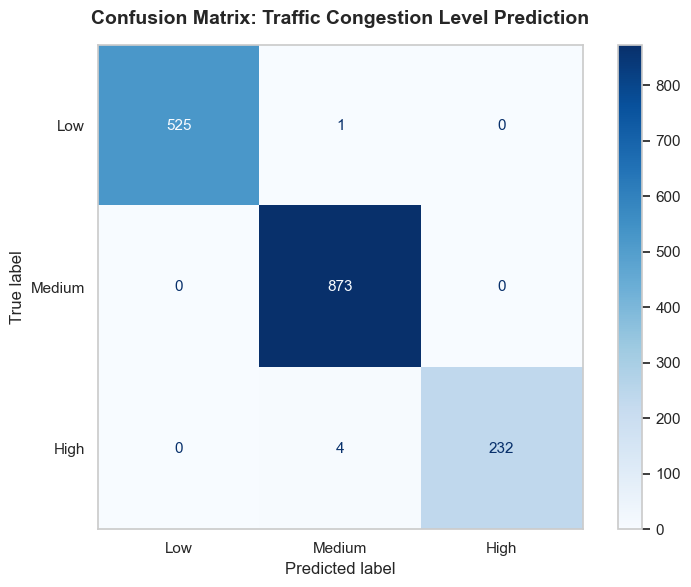

In [7]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title('Confusion Matrix: Traffic Congestion Level Prediction', fontsize=14, weight='bold', pad=15)
plt.grid(False)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

## 6. Model Serialization
We save our completed model pipeline (including preprocessors and the trained XGBoost estimator) to a serialized `.joblib` file. This lets us load the complete pipeline later and make predictions on raw inputs in production without repeating preprocessing.


In [8]:
# Save the model pipeline to disk
model_filename = "congestion_model.joblib"
joblib.dump(model_pipeline, model_filename)
print(f"Saved trained model pipeline to '{model_filename}'")

# Verify the file exists and its size
if os.path.exists(model_filename):
    size_mb = os.path.getsize(model_filename) / (1024 * 1024)
    print(f"Model saved successfully. File size: {size_mb:.2f} MB")

Saved trained model pipeline to 'congestion_model.joblib'
Model saved successfully. File size: 0.58 MB


## 7. Model Inference Demo
This cell demonstrates how to load the saved model pipeline and use it for predictions on new, raw incident inputs.


In [9]:
# Load the saved model to verify it works
loaded_pipeline = joblib.load(model_filename)
print("Saved model loaded successfully.")

# Create a sample raw input matching the feature columns
sample_input = pd.DataFrame([{
    'event_type': 'unplanned',
    'event_cause': 'accident',
    'priority': 'High',
    'requires_road_closure': True,
    'hour': 9,                  # Morning peak hour
    'day_of_week': 0,           # Monday
    'duration_hours': 1.5,      # 1.5 hours duration
    'zone': 'Central Zone 2',
    'junction': 'UrvashiJunction'
}])

# Predict
sample_pred = loaded_pipeline.predict(sample_input)[0]
sample_pred_proba = loaded_pipeline.predict_proba(sample_input)[0]

print(f"\nPrediction for sample input:")
print(f"- Predicted Congestion Level Code: {sample_pred} ({target_names[sample_pred]})")
print(f"- Probabilities: Low={sample_pred_proba[0]:.2%}, Medium={sample_pred_proba[1]:.2%}, High={sample_pred_proba[2]:.2%}")

Saved model loaded successfully.

Prediction for sample input:
- Predicted Congestion Level Code: 2 (High)
- Probabilities: Low=0.01%, Medium=0.14%, High=99.85%
